In [8]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn_lvq.glvq import GlvqModel
from scipy.optimize import minimize

In [9]:
class PatchedGlvqModel(GlvqModel):
    # use numpy exp (works with arrays)
    def phi(self, x):
        x = np.asarray(x)
        return 1.0 / (1.0 + np.exp(-self.beta * x))

    # derivative of phi using numpy
    def phi_prime(self, x):
        x = np.asarray(x)
        exp_term = np.exp(-self.beta * x)
        return self.beta * exp_term / (1.0 + exp_term) ** 2

    # pass flattened x0 to scipy.minimize
    def _optimize(self, x, y, random_state):
        label_equals_prototype = y[np.newaxis].T == self.c_w_
        res = minimize(
            fun=lambda vs: self._optfun(
                variables=vs, training_data=x,
                label_equals_prototype=label_equals_prototype),
            jac=lambda vs: self._optgrad(
                variables=vs, training_data=x,
                label_equals_prototype=label_equals_prototype,
                random_state=random_state),
            method='l-bfgs-b',
            x0=self.w_.ravel(),
            options={'disp': self.display, 'gtol': self.gtol,
                     'maxiter': self.max_iter}
        )
        # reshape result back to original prototype shape
        self.w_ = res.x.reshape(self.w_.shape)
        # assign iteration count if available
        self.n_iter_ = getattr(res, "nit", getattr(res, "niter", None))

In [10]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = PatchedGlvqModel()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Iris test accuracy (GLVQ): {acc*100:.2f}%")

Iris test accuracy (GLVQ): 90.00%


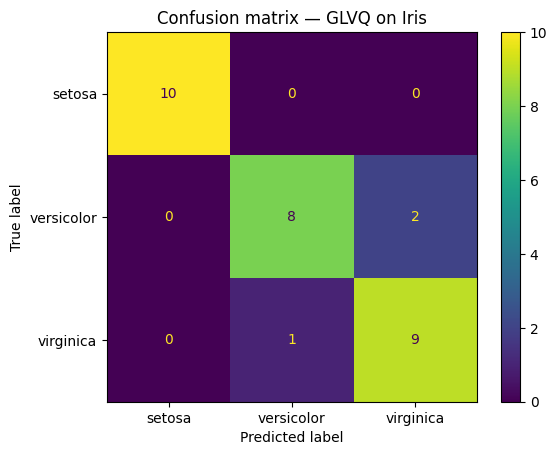

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=iris.target_names)
disp.plot(values_format='d')
plt.title("Confusion matrix — GLVQ on Iris")
plt.show()

In [14]:
print("Prototypes (model.w_):")
print(model.w_)
if hasattr(model, "c_w_"):
    print("Prototype labels (c_w_):", model.c_w_)
elif hasattr(model, "w_labels_"):
    print("Prototype labels (w_labels_):", model.w_labels_)


Prototypes (model.w_):
[[-1.05056726  0.71876997 -1.31420979 -1.26702644]
 [ 0.14811317 -0.6234699   0.0968188  -0.19939591]
 [ 0.81587961 -0.30677611  1.20545809  1.42923092]]
Prototype labels (c_w_): [0 1 2]
